In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd 
pd.set_option("display.max_columns", None)      # view ALL columns in DataFrames
# pd.reset_option("display.max_columns")        # reset to default
from pypalettes import load_cmap
from drawarrow import ax_arrow
from highlight_text import fig_text
# personalisation
plt.rcParams.update({
    "font.family": "Georgia",
    "font.size": 11,
    "lines.linewidth": 1,
})

# Import Data

In [2]:
df = pd.read_parquet("../data/strava_activities.parquet")

keep = [
    "activity_id", "name", "type",
    "start_datetime", "end_datetime",
    "date", "month", "weekday", "start_hour",
    "distance_km", "distance_miles",
    "moving_time_mins", "elapsed_time_mins",
    "avg_pace_km", "avg_pace_mile",
    "avg_hr", "max_hr", "avg_cadence_spm",
    "total_elev_gain",
    "shoe", "num_comments", "num_achievements", "num_kudos"
]

df = df[keep]

df = (
    df.groupby("month", observed=False)
    .size()
    .reset_index(name="num_activities")
    .sort_values(by="month", ascending=True)
)

df

,month,num_activities
0,January,79
1,February,71
2,March,80
3,April,79
4,May,77
5,June,80
6,July,82
7,August,88
8,September,63
9,October,43


# Bar Chart

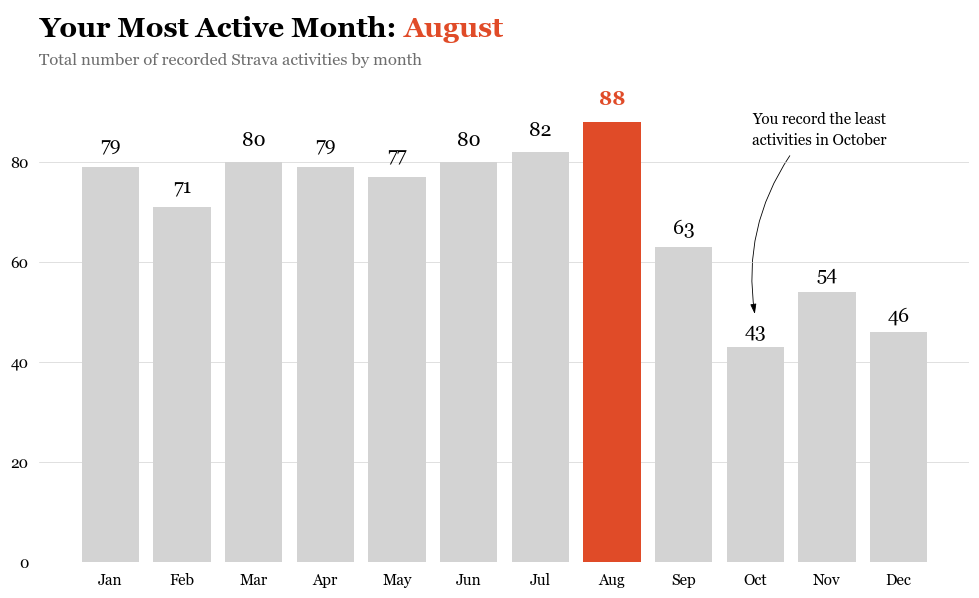

In [3]:
# choose a colour palette
cmap = load_cmap("Abbott")
colours = cmap.colors

# identify month with most activities
highlight_month = df.loc[df["num_activities"].idxmax(), "month"]

# colour mapping for bars (highlight the month with most activities and grey out the rest)
highlight_colour = colours[1]
colours_df = (df["month"] == highlight_month).map({
    True: highlight_colour,
    False: "lightgrey"
})

# create figure
fig, ax = plt.subplots(figsize=(12, 6))

# axes customisation
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.tick_params(axis="x", length=0, pad=8)    # spacing of x ticks (labels) from x-axis
ax.tick_params(axis="y", length=0, pad=8)    # spacing of y ticks (labels) from y-axis
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax.grid(
    axis="y", 
    color="lightgrey", 
    linewidth=0.5, 
    zorder=0            # draw gridlines before (behind) the bars
)

# plot horizontal bar chart
ax.bar(
    x=df["month"].str[:3],
    height=df["num_activities"],
    color=colours_df,
    zorder=3
)

# value annotations
for i in range(df.shape[0]):
    month = df["month"].iloc[i]
    value = df["num_activities"].iloc[i]
    ax.text(
        x=i,
        y=value * 1.03,
        s=f"{value:,}",
        va="bottom",
        ha="center",
        weight="bold" if month == highlight_month else None,
        color=highlight_colour if month == highlight_month else "black",
        fontsize=14
    )

# arrow: point to the lowest bar
idx_lowest = df["num_activities"].idxmin()
lowest_month = df.loc[idx_lowest, "month"]
x_head, y_head = idx_lowest, df["num_activities"].min()
x_text, y_text = x_head * 1.1, y_head * 1.9
ax_arrow(
    head_position=(x_head * 1.00, y_head * 1.14),
    tail_position=(x_text * 0.96, y_text),
    fill_head=True,
    head_width=1.8,
    head_length=6,
    color="black",
    radius=0.2,
    width=0.6,
)

# annotation text: state peak activity 
ax.text(
    x=x_text, y=y_text * 1.015,
    # s=f"the majority of\nyour activites started\naround {x_peak:.0f}:00",
    s=f"You record the least\nactivities in {lowest_month}",    
    ha="center",
    va="bottom",
    fontsize=11,
    linespacing=1.45
)

# chart title
x_value, y_value = 0.125, 1.02
fig_text(
    x=x_value, y=y_value,
    s=f"Your Most Active Month: <{highlight_month}>", 
    highlight_textprops=[
        {"color": highlight_colour, "weight": "bold"},
    ],
    fontsize=20,
    weight="bold"
)

# chart subtitle
fig.text(
    x=x_value, y=y_value * 0.92,
    s="Total number of recorded Strava activities by month",
    size=12,
    color="#6e6e6e"
)

# save figure as SVG
plt.savefig("../images/activities_by_month.svg", bbox_inches="tight")

plt.show()